In [8]:
import os, sys,json
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
REPO = '/home/mantovani/repo/generalize_knowledge'
os.chdir(REPO)                    # so 'data/...' paths also resolve
sys.path.insert(0, f'{REPO}/src')
import yaml, glob, sweep 
#cfg = yaml.safe_load(open('experiments/exp01_decl.yaml'))
cfg = yaml.safe_load(open('experiments/exp01_fic_decl_50.yaml'))

# point at the sweep results you want to watch:
TAG='facts_attr_v2' 
#RUN='fic_decl_en__anc_qa50-decl50_en' 
RUN = 'fic_qa-decl_en__anc_qa50-decl50_en'
#RUN='train_qa_forward-declarative_en__anchor_en80-it20'
FOLD=2
RESULTS = f'data/{TAG}/{RUN}/fold{FOLD}/sweep'
print('watching:', RESULTS)


watching: data/facts_attr_v2/fic_qa-decl_en__anc_qa50-decl50_en/fold2/sweep


In [9]:
# ===== progress: how many of the expected runs are done =====
from transformers import AutoConfig
snap=os.path.join(cfg['models']['target'],'snapshots')
mp=os.path.join(snap,os.listdir(snap)[0]) if os.path.isdir(snap) else cfg['models']['target']
nL=AutoConfig.from_pretrained(mp).num_hidden_layers
done=glob.glob(f'{RESULTS}/runs/*/summary.json')
evald=[p for p in done if os.path.isdir(os.path.join(os.path.dirname(p),'evaluated'))]
print(f'configs per seed = {nL+2} (all + {nL} singles + base)')
print(f'trained: {len(done)}   evaluated: {len(evald)}')
RESULTS

configs per seed = 34 (all + 32 singles + base)
trained: 34   evaluated: 34


'data/facts_attr_v2/fic_qa-decl_en__anc_qa50-decl50_en/fold2/sweep'

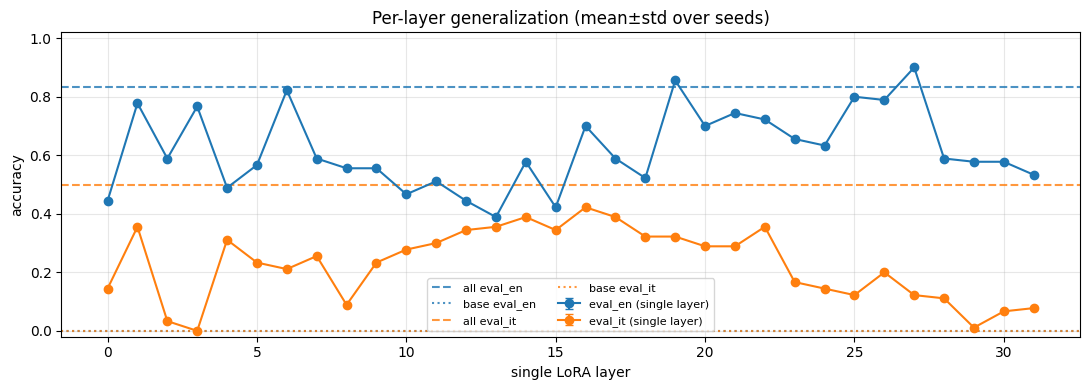

34 result records  (seeds: [0])


In [10]:
# ===== THE PLOT: upper bound (all), base, and each single layer (mean±std over seeds) =====
# re-run this cell anytime while run.py is training to watch it fill in
import importlib; importlib.reload(sweep)
sweep.plot_sweep(RESULTS)


In [7]:
import glob, os

# every run dir that has a saved adapter = training finished for that config/seed/layer
runs = glob.glob("data/facts_attr_v2/*/fold*/sweep/runs/*/")
trained_runs = [d for d in runs if os.path.isdir(os.path.join(d, "adapter"))]

# collapse to unique (config, fold) — strip everything from /sweep/runs/... onward
done_cf = sorted({d.split("/sweep/runs/")[0] for d in trained_runs})

print(f"{len(trained_runs)} trained run-dirs across {len(done_cf)} (config, fold) combos:\n")
for cf in done_cf:
    n = sum(1 for d in trained_runs if d.startswith(cf))
    # 34 = all + 32 singles + base, per seed; 3 seeds => 102 when a (config,fold) is fully done
    print(f"  {n:3d}/102 runs   {cf}")

264 trained run-dirs across 6 (config, fold) combos:

   45/102 runs   data/facts_attr_v2/fic_decl_en__anc_qa50-decl50_en/fold0
   33/102 runs   data/facts_attr_v2/fic_decl_en__anc_qa50-decl50_en/fold1
   33/102 runs   data/facts_attr_v2/fic_decl_en__anc_qa50-decl50_en/fold2
   87/102 runs   data/facts_attr_v2/fic_qa-decl_en__anc_qa50-decl50_en/fold0
   33/102 runs   data/facts_attr_v2/fic_qa-decl_en__anc_qa50-decl50_en/fold1
   33/102 runs   data/facts_attr_v2/fic_qa-decl_en__anc_qa50-decl50_en/fold2


In [8]:
RESULTS

'data/facts_attr_v2/fic_qa-decl_en__anc_qa50-decl50_en/fold0/sweep'

In [9]:
# ===== optional: results table =====
recs=[json.load(open(p)) for p in glob.glob(f'{RESULTS}/runs/*/summary.json')]
tiers=sorted({k for r in recs for k in r if k.startswith('eval_')})
from collections import defaultdict
import statistics as st
agg=defaultdict(lambda: defaultdict(list))
for r in recs:
    key=r['layers']
    for t in tiers:
        if r.get(t) is not None: agg[key][t].append(r[t])
def order(k):
    return -1 if k=='all' else 999 if k=='base' else int(k[1:])
print('config   ' + '  '.join(f'{t:>10}' for t in tiers))
for k in sorted(agg, key=order):
    row=' '.join(f'{st.mean(agg[k][t]):.2f}±{(st.pstdev(agg[k][t]) if len(agg[k][t])>1 else 0):.2f}'
                 if agg[k][t] else '   -   ' for t in tiers)
    print(f'{k:8s} {row}')


KeyError: 'layers'